# **Building a SimpleRNN Model for Weather Temperature Prediction**

---
**Objective**

The goal of this assignment is to design, implement, and evaluate a **Recurrent Neural Network (RNN)** model (using **SimpleRNN**) to forecast the next day's temperature based on past weather data.

---
**Dataset**


Use the Daily Weather Dataset

● Example: Daily Weather Dataset - Kaggle

● Key Features:

    ○ Date.

    ○ Temperature (target variable).

    ○ Humidity.

    ○ Wind Speed.

    ○ Pressure (optional).

---
**Tasks**

**Part A: Data Understanding and Preprocessing**
1. Load the dataset and explore:

    ○ Display first 10 rows.

    ○ Plot temperature trends over time.

    ○ Check for missing values.

2. Preprocess the data:

    ○ Handle missing values (impute/remove).

    ○ Normalize values using MinMaxScaler (so RNN converges faster).

    ○ Create **input sequences**:

         ■ Use **past 7-14 days' weather data** (temperature, humidity, wind speed) as input.

         ■ Target: **next day's temperature**.
    ○ Split dataset into **train, validation, and test sets**.

---
**Part B: RNN Model Development**

3. Build a **SimpleRNN model** using TensorFlow/Keras:

    ○ Input layer (with shape = sequence length * number of features).

    ○ SimpleRNN layer (e.g., 32-64 units).

    ○ Dropout layer (optional, to avoid overfitting).

    ○ Dense layer with 1 unit (linear activation for regression).
4. Compile the model:

    ○ Loss: **Mean Squared Error (MSE)**.

    ○ Optimizer: Adam.

    ○ Metrics: Mean Absolute Error (MAE).
5. Train the model on training data:

    ○ Batch size: 32

    ○ Epochs: 50–100

    ○ Use validation data to monitor performance.

    ○ Plot training vs validation **loss curves**.

---
**Part C: Model Evaluation & Forecasting**

6. Evaluate the model on the **test set**:

    ○ Calculate **RMSE, MAE, and R2 score**.

    ○ Plot **predicted vs actual temperatures** for the test period.

7. Forecast the **next 7 days of temperature** using the trained model and visualize predictions vs recent historical data.

In [ ]:
#Installing Kaggle.
!pip install -q kaggle

In [ ]:
#Creating kaggle.json using token.
import json

kaggle_config = {
    "username": "layamarybasil",
    "key": "KGAT_7187fb8aa18b3f4220383d5b7bd6643a"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json file created")

kaggle.json file created


In [ ]:
#Moving kaggle.json to correct folder.
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#Testing Kaggle API.
!kaggle datasets list

ref                                                            title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
bhushandivekar/video-game-sales-and-industry-data-1980-2024    🎮 Video Game Sales & Industry Data (1980 - 2024)      2437021  2026-03-14 08:27:51.750000           1033         24                1  
ssssws/chocolate-sales-dataset-2023-2024                       Chocolate Sales Dataset 2023 - 2024                  24420255  2026-03-07 04:58:02.387000           4060         73                1  
grandmaster07/student-exam-performance-dataset-analysis        Student Exam Performance Dataset Analysis               96178  2026-02-10 09:47:13.350000           7833        142                1  
rhythmghai

In [ ]:
# Download Daily Weather Dataset
!kaggle datasets download -d muthuj7/weather-dataset

Dataset URL: https://www.kaggle.com/datasets/muthuj7/weather-dataset
License(s): CC0-1.0
weather-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Unzipping Dataset
!unzip weather-dataset.zip

Archive:  weather-dataset.zip
replace weatherHistory.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: weatherHistory.csv      


**Tasks**

**Part A: Data Understanding and Preprocessing**

1. Load the dataset and explore:

    ○ Display first 10 rows.

    ○ Plot temperature trends over time.

    ○ Check for missing values.

In [ ]:
#Load the dataset & display first 10 rows.

#Importing required libraries.
import pandas as pd

#Load dataset.
df = pd.read_csv("weatherHistory.csv")

# Display first 10 rows.
df.head(10)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


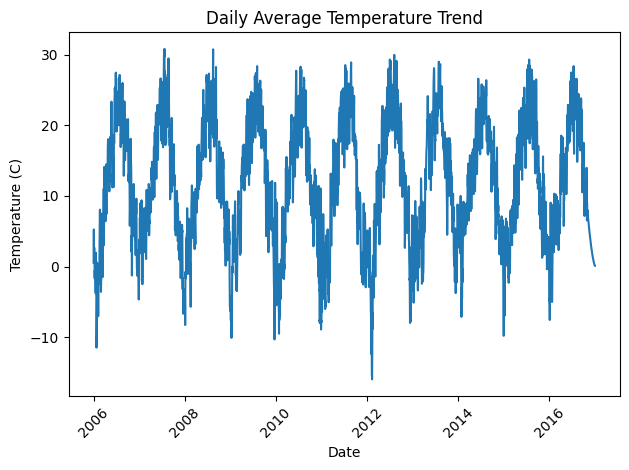

In [ ]:
#Plot temperature trends over time.

#Importing required libraries.
import matplotlib.pyplot as plt

# Convert to datetime
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)

# Sort values
df = df.sort_values(by='Formatted Date')

# Set index
df.set_index('Formatted Date', inplace=True)

# Resample
daily_temp = df['Temperature (C)'].resample('D').mean()

# Plot
plt.figure()
plt.plot(daily_temp)
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.title("Daily Average Temperature Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Check missing values.
df.isnull().sum()

,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0
Pressure (millibars),0


2. Preprocess the data:

    ○ Handle missing values (impute/remove).

    ○ Normalize values using MinMaxScaler (so RNN converges faster).

    ○ Create **input sequences**:

       ■ Use **past 7-14 days' weather data** (temperature, humidity, wind speed)
        as input.

       ■ Target: **next day's temperature**.
    
    ○ Split dataset into **train, validation, and test sets**.

In [ ]:
#Handle missing values (impute/remove).

#Fill missing values in 'Precip Type' with mode.
df['Precip Type'] = df['Precip Type'].fillna(df['Precip Type'].mode()[0])

#Verify again.
df.isnull().sum()

,0
Summary,0
Precip Type,0
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0
Pressure (millibars),0


In [ ]:
#Normalize values using MinMaxScaler (so RNN converges faster).

#Import required libraries.
from sklearn.preprocessing import MinMaxScaler

#Select features to normalize.
features = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']

#Initialize scaler.
scaler = MinMaxScaler()

#Apply scaling.
scaled_data = scaler.fit_transform(df[features])

In [ ]:
#Create input sequences.

import numpy as np

#Use scaled data.
data = scaled_data

#Sequence length (7 days).
time_steps = 7

#Function to create sequences.
def create_sequences(data, time_steps):
    X, y = [], []

    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])
        y.append(data[i, 0])  #Temperature.

    return np.array(X), np.array(y)

#Create sequences.
X, y = create_sequences(data, time_steps)

#Check shapes.
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96446, 7, 3)
y shape: (96446,)


In [ ]:
#Split dataset into train, validation, and test sets.

#Define sizes.
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

#Train set.
X_train = X[:train_size]
y_train = y[:train_size]

#Validation set.
X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

#Test set.
X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]


#Check shapes.
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (67512, 7, 3)
X_val shape: (14466, 7, 3)
X_test shape: (14468, 7, 3)


**Part B: RNN Model Development**

3. Build a **SimpleRNN model** using TensorFlow/Keras:

    ○ Input layer (with shape = sequence length * number of features).

    ○ SimpleRNN layer (e.g., 32–64 units).

    ○ Dropout layer (optional, to avoid overfitting).

    ○ Dense layer with 1 unit (linear activation for regression).

In [ ]:
#Import required libraries.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

#Build model.
model = Sequential()

#Input layer + SimpleRNN.
model.add(SimpleRNN(50, input_shape=(X_train.shape[1], X_train.shape[2])))

#Dropout layer.
model.add(Dropout(0.2))

#Output layer.
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4. Compile the model:

    ○ Loss: **Mean Squared Error (MSE)**.

    ○ Optimizer: Adam.

    ○ Metrics: Mean Absolute Error (MAE).

In [ ]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_7 (SimpleRNN)        │ (None, 50)             │         2,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,751 (10.75 KB)

 Trainable params: 2,751 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

Train the model on training data:

    ○ Batch size: 32.

    ○ Epochs: 50 - 100.

    ○ Use validation data to monitor performance.

    ○ Plot training vs validation loss curves.

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0033 - mae: 0.0419 - val_loss: 9.8366e-04 - val_mae: 0.0259
Epoch 2/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0012 - mae: 0.0260 - val_loss: 3.6301e-04 - val_mae: 0.0138
Epoch 3/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 8.0268e-04 - mae: 0.0212 - val_loss: 3.3702e-04 - val_mae: 0.0140
Epoch 4/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 7.0160e-04 - mae: 0.0197 - val_loss: 3.4157e-04 - val_mae: 0.0147
Epoch 5/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 6.6152e-04 - mae: 0.0190 - val_loss: 2.6917e-04 - val_mae: 0.0118
Epoch 6/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 6.4234e-04 - mae: 0.0187 - val_loss: 2.7212e-04 - val_mae: 0.0123
Epoch 7/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 6.2065e-04 - mae: 0.0183 - val_loss: 3.1507e-04 - val_mae: 0.0131
Epoch 8/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 6.2094e-04 - mae: 0.0182 - val_loss: 2.8156e

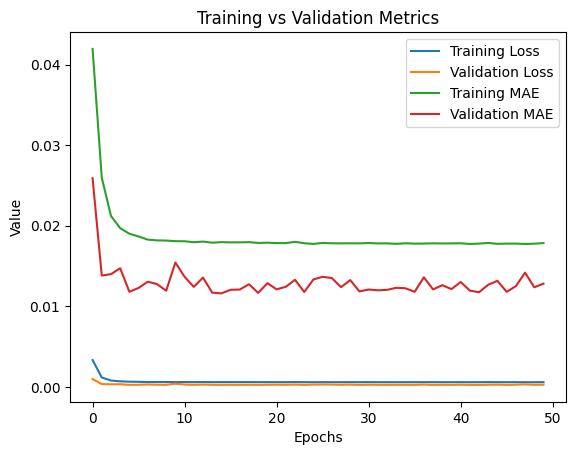

In [ ]:
#Plot loss curves.
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel("Epochs")
plt.ylabel("Value")
plt.title("Training vs Validation Metrics")
plt.legend()
plt.show()

**Part C: Model Evaluation & Forecasting**

Evaluate the model on the **test set**:

    ○ Calculate RMSE, MAE, and R2 score.

    ○ Plot predicted vs actual temperatures for the test period.

In [ ]:
#Predict on test data.
y_pred = model.predict(X_test)

453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
#Prepare arrays for inverse scaling.
y_test_actual = np.zeros((len(y_test), 3))
y_pred_actual = np.zeros((len(y_pred), 3))

#Fill temperature column (index 0).
y_test_actual[:, 0] = y_test
y_pred_actual[:, 0] = y_pred.flatten()

#Inverse transform.
y_test_actual = scaler.inverse_transform(y_test_actual)[:, 0]
y_pred_actual = scaler.inverse_transform(y_pred_actual)[:, 0]

In [ ]:
#Import required libraries.
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#RMSE.
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

#MAE.
mae = mean_absolute_error(y_test_actual, y_pred_actual)

#R2 Score.
r2 = r2_score(y_test_actual, y_pred_actual)

#Print results.
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 1.0558229353261754
MAE: 0.7954558850573834
R2 Score: 0.9869502482287118


453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


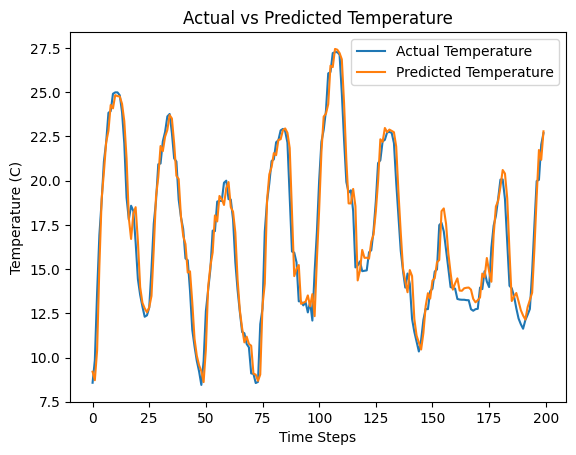

In [ ]:
# Step 1: Predict
y_pred = model.predict(X_test)

# Step 2: Convert back to original scale
y_test_actual = np.zeros((len(y_test), 3))
y_pred_actual = np.zeros((len(y_pred), 3))

y_test_actual[:, 0] = y_test
y_pred_actual[:, 0] = y_pred.flatten()

y_test_actual = scaler.inverse_transform(y_test_actual)[:, 0]
y_pred_actual = scaler.inverse_transform(y_pred_actual)[:, 0]

# Step 3: Plot
plt.figure()

plt.plot(y_test_actual[:200], label='Actual Temperature')
plt.plot(y_pred_actual[:200], label='Predicted Temperature')

plt.xlabel("Time Steps")
plt.ylabel("Temperature (C)")
plt.title("Actual vs Predicted Temperature")
plt.legend()

plt.show()

7. Forecast the **next 7 days of temperature** using the trained model and visualize predictions vs recent historical data.

In [ ]:
#Take last available sequence.
last_sequence = X_test[-1]

In [ ]:
# Store predictions
future_predictions = []

# Copy last sequence
current_sequence = X_test[-1].copy()

# Predict next 7 days
for i in range(7):

    # Reshape for model input
    current_sequence_reshaped = current_sequence.reshape(1, 7, 3)

    # Predict next value
    next_pred = model.predict(current_sequence_reshaped)

    # Store only temperature
    future_predictions.append(next_pred[0, 0])

    # Create new row (keep other features same)
    new_row = current_sequence[-1].copy()
    new_row[0] = next_pred[0, 0]

    # Update sequence (sliding window)
    current_sequence = np.vstack((current_sequence[1:], new_row))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [ ]:
# Convert predictions back to original scale

future_array = np.zeros((len(future_predictions), 3))
future_array[:, 0] = future_predictions

future_predictions_actual = scaler.inverse_transform(future_array)[:, 0]

In [ ]:
# Get last date from dataset
last_date = df.index[-1]

# Create next 7 days dates
future_dates = pd.date_range(start=last_date, periods=8, freq='D')[1:]

# Get recent actual data (last 7 days)
recent_actual = df['Temperature (C)'].resample('D').mean().iloc[-7:]

recent_dates = recent_actual.index

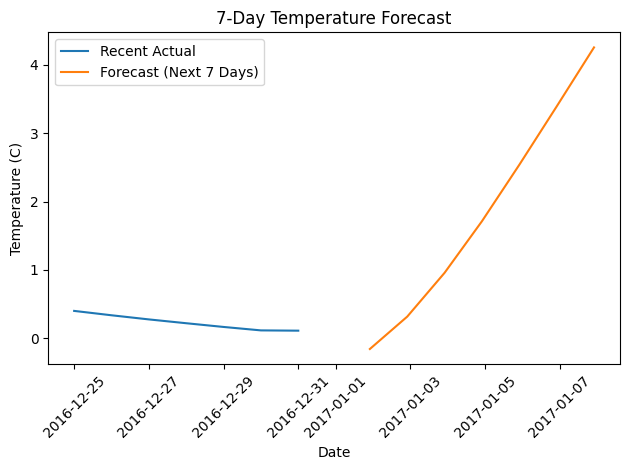

In [ ]:
plt.figure()

# Plot recent actual data
plt.plot(recent_dates, recent_actual, label='Recent Actual')

# Plot future predictions
plt.plot(future_dates, future_predictions_actual, label='Forecast (Next 7 Days)')

plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.title("7-Day Temperature Forecast")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()